In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

## Conjugate Gradient

Conjugate gradient methods represent a kind of steepest descent approach “with a twist”. With steepest descent, we begin our minimization of a function $f$ starting at $x_0$ by traveling in the direction of the negative gradient $-f^\prime(x_0)$. In subsequent steps, we continue to travel in the direction of the negative gradient evaluated at each successive point until convergence.

The conjugate gradient approach begins in the same manner, but diverges from steepest descent after the first step. In subsequent steps, the direction of travel must be *conjugate* to the direction most recently traveled. Two vectors $u$ and $v$ are conjugate with respect to the matrix $A$ if $u^\prime Av = 0$.

Before we go further, let’s take a concrete example. Suppose we want to minimize the quadratic function

$$
f(x) = \frac{1}{2} x^\prime Ax - x^\prime b

$$

where $x$ is a $p$-dimensional vector and $A$ is a $p\times p$ symmetric matrix. Starting at a point $x_0$, both steepest descent and conjugate gradient would take us in the direction of $p_0 = -f^\prime(x_0) = b-Ax_0$, which is the negative gradient. Once we have moved in that direction to the point $x_1$, the next direction, $p_1$ must satisfy $p_0^\prime A p_1 = 0$. So we can begin with the steepest descent direction $-f^\prime(x_1)$ but then we must modify it to make it conjugate to $p_0$. The constraint $p_0^\prime Ap_1=0$ allows us to back calculate the next direction, starting with $-f^\prime(x_1)$, because we have

$$
p_0^\prime A\left(-f^\prime - \frac{p_0^\prime A(-f^\prime)}{p_0^\prime Ap_0}p_0\right)=0.

$$

Without the presence of the matrix $A$, this is process is simply [Gram-Schmidt orthogonalization](https://en.wikipedia.org/wiki/Gram–Schmidt_process). We can continue with this process, each time taking the steepest descent direction and modifying it to make it conjugate with the previous direction. The conjugate gradient process is (somewhat) interesting here because for minimizing a $p$-dimensional quadratic function it will converge within $p$ steps.

In reality, we do not deal with exactly quadratic functions and so the above-described algorithm is not feasible. However, the *nonlinear conjugate gradient method* draws from these ideas and develops a reasonable algorithm for finding the minimum of an arbitrary smooth function. It has the feature that it only requires storage of two gradient vectors, which for large problems with many parameters, is a significant savings in storage versus Newton-type algorithms which require storage of a gradient vector and a $p\times p$ Hessian matrix.

The Fletcher-Reeves nonlinear conjugate gradient algorithm works as follows. Starting with $x_0$,

1. Let $p_0 = -f^\prime(x_0)$.
2. Solve

$$
\min_{\alpha>0} f(x_0 + \alpha p_0)

$$

for $\alpha$ and set $x_1=x_0+\alpha p_0$.
3. For $n = 1, 2, \dots$ let $r_n = -f^\prime(x_n)$ and $r_{n-1}=-f^\prime(x_{n-1})$. Then set

$$
\beta_n = \frac{r_n^\prime r_n}{r_{n-1}^\prime r_{n-1}}.

$$

Finally, update $p_{n} = r_n + \beta_n * p_{n-1}$, and let

$$
x_{n+1} = x_n + \alpha^\star p_{n},

$$

where $\alpha^\star$ is the solution to the problem $\min_{\alpha > 0}f(x_n + \alpha p_n)$. Check convergence and if not converged, repeat.

It is perhaps simpler to describe this method with an illustration. Here, we show the contours of a 2-dimensional function.


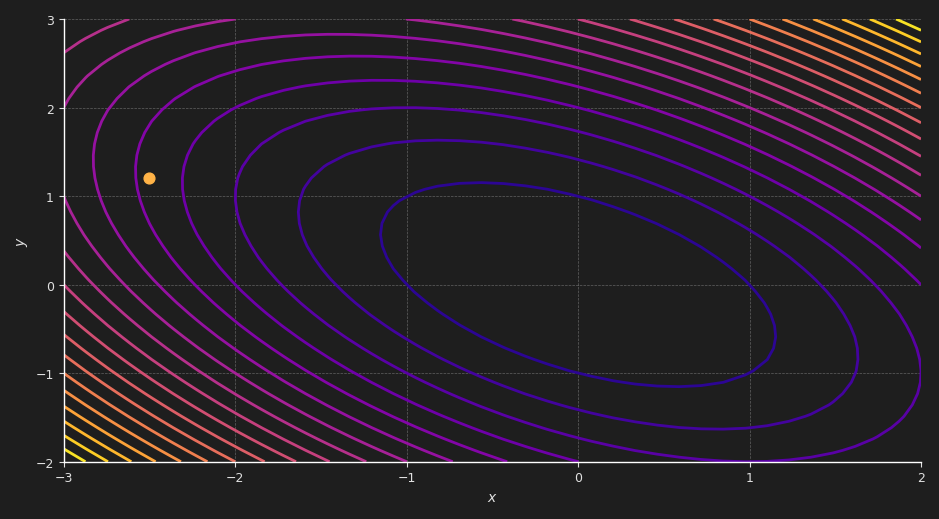

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# f(x,y) = x^2 + y^2 + a*x*y  (a=1)
a = 1
f = lambda x, y: x**2 + y**2 + a * x * y
grad_f = lambda x, y: np.array([2*x + a*y, 2*y + a*x])

n = 40
xpts = np.linspace(-3, 2, n)
ypts = np.linspace(-2, 3, n)
xx, yy = np.meshgrid(xpts, ypts)
z = f(xx, yy)

x0, y0 = -2.5, 1.2  # starting point

def contour_base():
    """Return (fig, ax) with contour plot and starting point marked."""
    fig, ax = plt.subplots()
    ax.contour(xpts, ypts, z, levels=20)
    ax.scatter([x0], [y0], color=C['orange'], zorder=5, s=60)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    return fig, ax

def draw_arrow(ax, xs, ys, xe, ye, color='white', lw=2, ls='-'):
    ax.annotate('', xy=(xe, ye), xytext=(xs, ys),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                linestyle=ls, mutation_scale=15))

fig, ax = contour_base()
plt.tight_layout()


We will use as a starting point the point $(-2.5, 1.2)$, as indicated in the figure above.

From the figure, it is clear that ideally we would be able to travel in the direction that would take us directly to the minimum of the function, shown here.


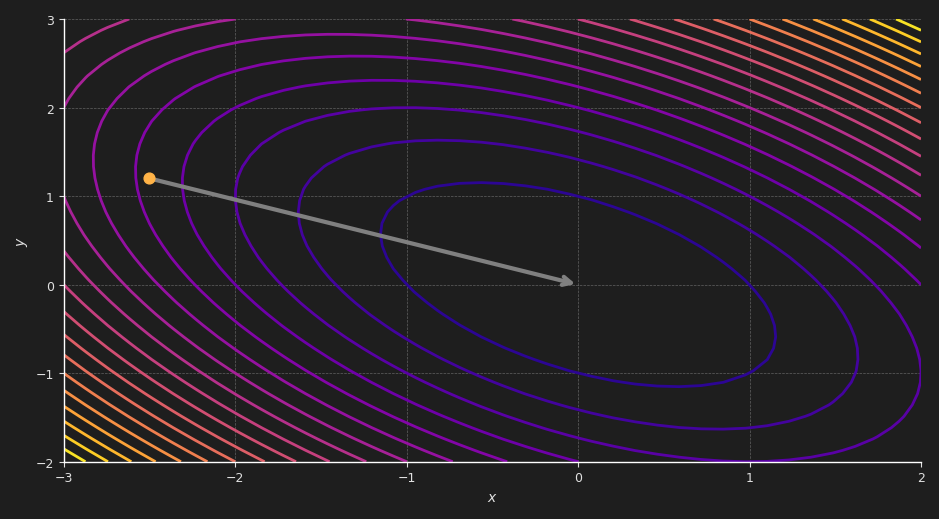

In [3]:
fig, ax = contour_base()
draw_arrow(ax, x0, y0, 0, 0, color='gray', lw=3)
plt.tight_layout()


If only life were so easy? The idea behind conjugate gradient is the construct that direction using a series of conjugate directions. First we start with the steepest descent direction. Here, we extract the gradient and find the optimal $\alpha$ value (i.e. the step size).


In [4]:
# Steepest descent direction from x0
p0 = -grad_f(x0, y0)

# Line search: find alpha that minimises f along direction p0 from x0
f_line = lambda alpha: f(x0 + alpha * p0[0], y0 + alpha * p0[1])
op = optimize.minimize_scalar(f_line, bounds=(0, 4), method='bounded')
alpha = op.x
print(f"Steepest descent direction: p0 = {p0}")
print(f"Optimal step size: alpha = {alpha:.4f}")


Steepest descent direction: p0 = [3.8 0.1]
Optimal step size: alpha = 0.4872


Now that we’ve computed the gradient and the optimal $\alpha$, we can take a step in the steepest descent direction


In [5]:
x1 = x0 + alpha * p0[0]
y1 = y0 + alpha * p0[1]
print(f"Next point: x1 = {x1:.4f}, y1 = {y1:.4f}")


Next point: x1 = -0.6487, y1 = 1.2487


and plot our progress to date.


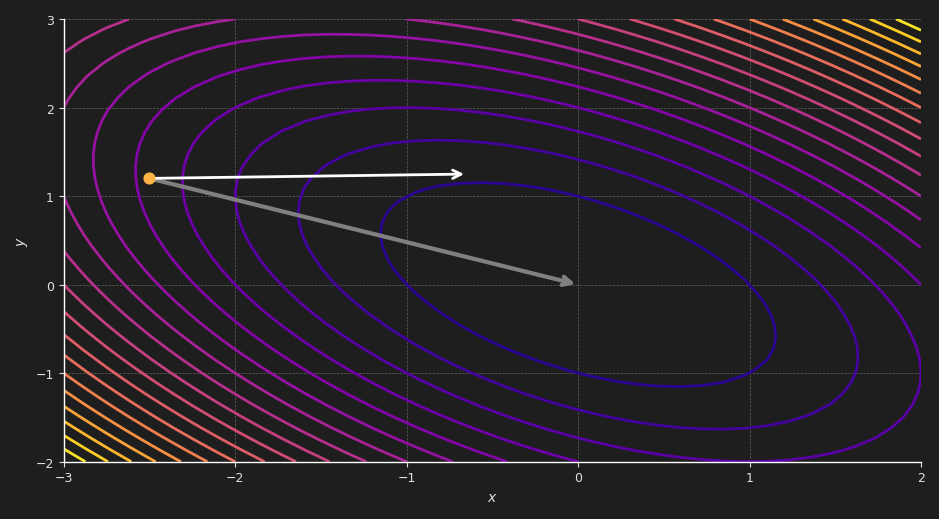

In [6]:
fig, ax = contour_base()
draw_arrow(ax, x0, y0, 0, 0, color='gray', lw=3)
draw_arrow(ax, x0, y0, x1, y1)
plt.tight_layout()


Now we need to compute the next direction in which to travel. We begin with the steepest descent direction again. The figure below shows what direction that would be (without any modifications for conjugacy).


In [7]:
# Steepest descent direction from x1
p1_sd = -grad_f(x1, y1)
f_line_sd = lambda alpha: f(x1 + alpha * p1_sd[0], y1 + alpha * p1_sd[1])
op_sd = optimize.minimize_scalar(f_line_sd, bounds=(0, 4), method='bounded')
alpha_sd = op_sd.x
x2 = x1 + alpha_sd * p1_sd[0]
y2 = y1 + alpha_sd * p1_sd[1]
print(f"Steepest descent direction from x1: p1 = {p1_sd}")
print(f"Next point (steepest descent): x2 = ({x2:.4f}, {y2:.4f})")


Steepest descent direction from x1: p1 = [ 0.04865138 -1.84875253]
Next point (steepest descent): x2 = (-0.6237, 0.2994)


Now we can plot the next direction that is chosen by the usual steepest descent approach.


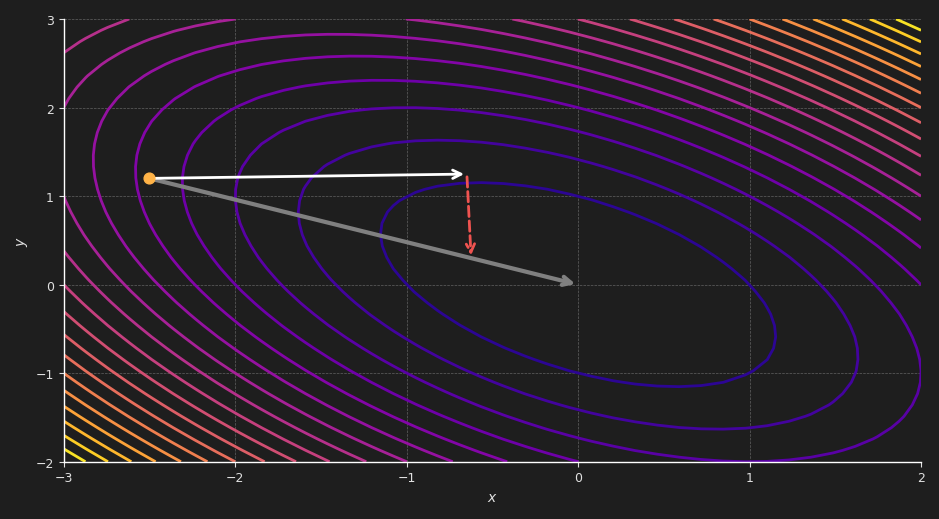

In [8]:
fig, ax = contour_base()
draw_arrow(ax, x0, y0, 0, 0, color='gray', lw=3)
draw_arrow(ax, x0, y0, x1, y1)
draw_arrow(ax, x1, y1, x2, y2, color=C['red'], ls='--')
plt.tight_layout()


However, the conjugate gradient approach computes a slightly different direction in which to travel.


In [9]:
# Fletcher-Reeves: beta = ||r1||^2 / ||r0||^2
r0 = p0                      # = -grad_f(x0, y0)
r1 = -grad_f(x1, y1)         # = -gradient at x1
beta = np.dot(r1, r1) / np.dot(r0, r0)
p1_cg = r1 + beta * p0       # conjugate gradient direction

f_line_cg = lambda alpha: f(x1 + alpha * p1_cg[0], y1 + alpha * p1_cg[1])
op_cg = optimize.minimize_scalar(f_line_cg, bounds=(0, 4), method='bounded')
alpha_cg = op_cg.x
x2c = x1 + alpha_cg * p1_cg[0]
y2c = y1 + alpha_cg * p1_cg[1]
print(f"Fletcher-Reeves beta = {beta:.4f}")
print(f"CG direction: p1 = {p1_cg}")
print(f"Next point (CG): x2c = ({x2c:.4f}, {y2c:.4f})")


Fletcher-Reeves beta = 0.2367
CG direction: p1 = [ 0.94809504 -1.82508296]
Next point (CG): x2c = (0.0000, -0.0000)


Finally, we can plot the direction in which the conjugate gradient method takes.


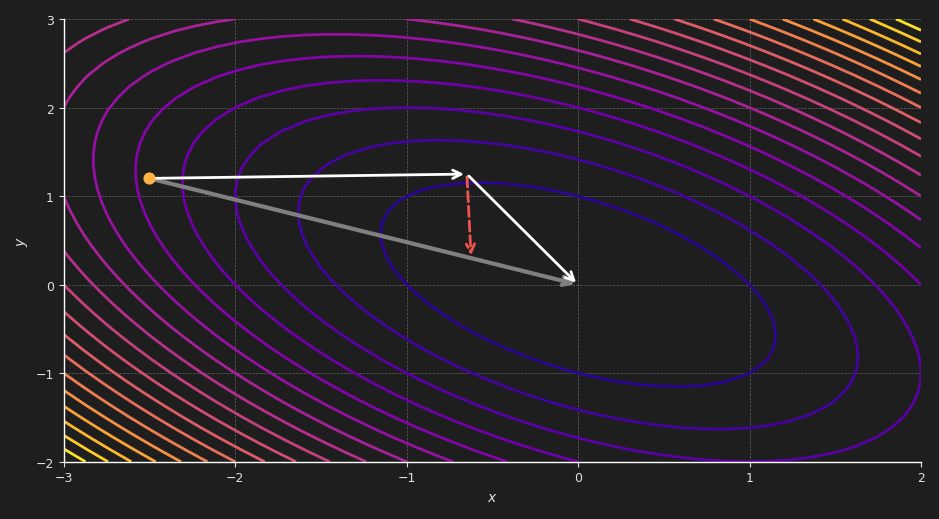

In [10]:
fig, ax = contour_base()
draw_arrow(ax, x0, y0, 0, 0, color='gray', lw=3)
draw_arrow(ax, x0, y0, x1, y1)
draw_arrow(ax, x1, y1, x2, y2, color=C['red'], ls='--')
draw_arrow(ax, x1, y1, x2c, y2c)
plt.tight_layout()


In this case, because the target function was exactly quadratic, the process converged on the minimum in exactly 2 steps. We can see that the steepest descent algorithm would have taken many more steps to wind its way towards the minimum.
